In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [58]:
summary_path = Path("/Users/bigrorz/UnityProjects/MultipleStyleRendering/ProfilingLogs/summary.csv")

raw_df = pd.read_csv(summary_path)

group_cols = [
    "test_name",
    "scene",
    "variable",
    "value",
    "render_mode",
    "N",
    "K",
    "styles_per_object",
]

metric_cols = [
    "mean_cpu_ms",
    "median_cpu_ms",
    "p95_cpu_ms",
    "p99_cpu_ms",
    "max_cpu_ms",
    "std_cpu_ms",
    "mean_gpu_ms",
    "median_gpu_ms",
    "p95_gpu_ms",
    "p99_gpu_ms",
    "max_gpu_ms",
    "std_gpu_ms",
]

agg_df = (
    raw_df.groupby(group_cols, as_index=False)[metric_cols]
    .mean()
    .sort_values(["test_name", "render_mode", "value"])
)

test_dfs = {
    test_name: df.sort_values(["value", "render_mode"]).reset_index(drop=True)
    for test_name, df in agg_df.groupby("test_name")
}

print("Loaded tests:")
for name, df in test_dfs.items():
    print(f"  {name}: {len(df)} rows")


Loaded tests:
  BBoxCondenseScaling_SameStyle_Merge: 10 rows
  BBoxCondenseScaling_SameStyle_NoMerge: 10 rows


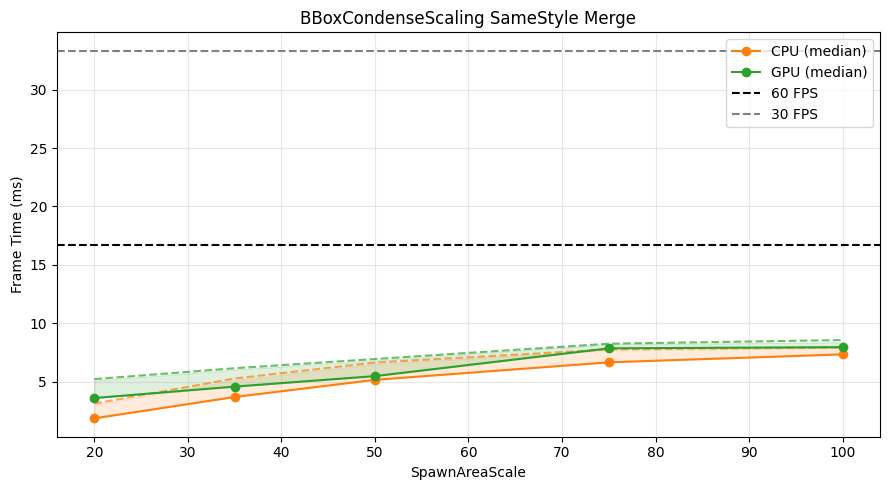

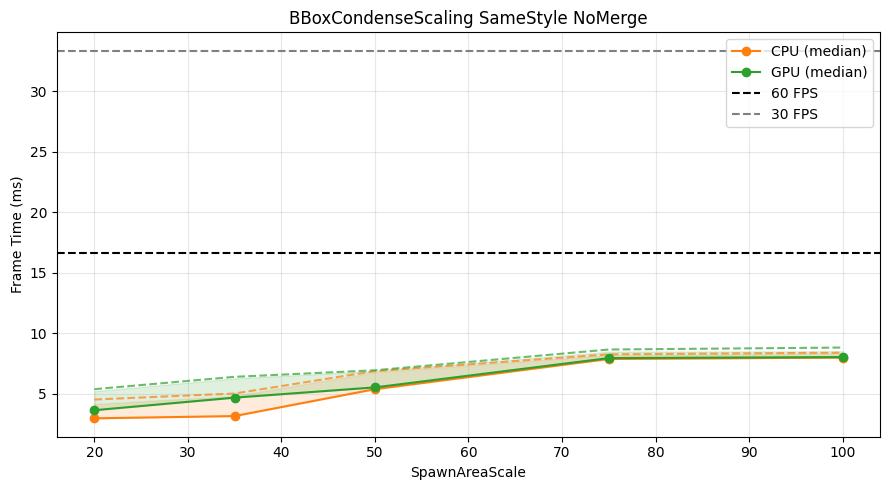

In [56]:
# consistent colours
mode_colors = {
    "Fullscreen": "C0",
    "CPU": "C1",
    "GPU": "C2",
}

# pretty names for variables
variable_labels = {
    "N": "Total Styles (N)",
    "K": "Active Styles (K)",
    "StylesPerObject": "Styles per Object",
    "ObjectCount": "Object Count",
    "Coverage": "Coverage (%)",
}

def format_title(name):
    return name.replace("_", " ")

for test_name, test_df in test_dfs.items():
    test_df = test_df.sort_values(["value", "render_mode"])

    plt.figure(figsize=(9, 5))

    for render_mode in ["Fullscreen", "CPU", "GPU"]:
        mode_df = test_df[test_df["render_mode"] == render_mode].sort_values("value")

        if mode_df.empty:
            continue

        x = mode_df["value"].values
        median = mode_df["median_gpu_ms"].values
        p95 = mode_df["p95_gpu_ms"].values
        p99 = mode_df["p99_gpu_ms"].values

        color = mode_colors[render_mode]

        # median line
        plt.plot(
            x,
            median,
            marker="o",
            color=color,
            label=f"{render_mode} (median)"
        )

        # p95 band
        plt.fill_between(
            x,
            median,
            p95,
            color=color,
            alpha=0.15
        )

        # p99 dashed
        plt.plot(
            x,
            p99,
            linestyle="--",
            color=color,
            alpha=0.7
        )

    # reference lines
    plt.axhline(16.67, linestyle="--", color="black", label="60 FPS")
    plt.axhline(33.33, linestyle="--", color="grey", label="30 FPS")

    # axis labels
    variable_key = test_df["variable"].iloc[0]
    xlabel = variable_labels.get(variable_key, variable_key)

    plt.title(f"{format_title(test_name)}")
    plt.xlabel(xlabel)
    plt.ylabel("Frame Time (ms)")

    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

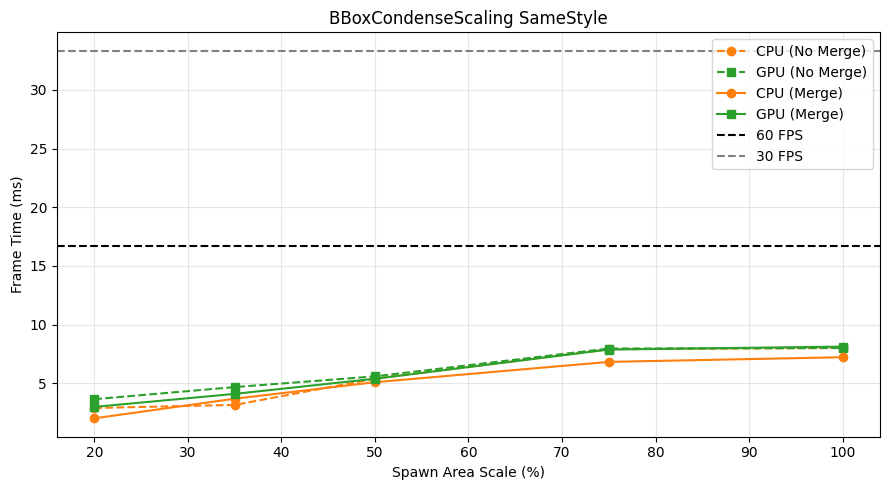

In [59]:
mode_styles = {
    ("CPU", "NoMerge"): {"linestyle": "--", "marker": "o"},
    ("CPU", "Merge"):   {"linestyle": "-",  "marker": "o"},
    ("GPU", "NoMerge"): {"linestyle": "--", "marker": "s"},
    ("GPU", "Merge"):   {"linestyle": "-",  "marker": "s"},
}

mode_colors = {
    "CPU": "C1",
    "GPU": "C2",
}

variable_labels = {
    "N": "Total Styles (N)",
    "K": "Active Styles (K)",
    "StylesPerObject": "Styles per Object",
    "ObjectCount": "Object Count",
    "Coverage": "Coverage (%)",
    "SpawnAreaScale": "Spawn Area Scale (%)",
}

def base_ablation_name(test_name):
    return (
        test_name
        .replace("_NoMerge", "")
        .replace("_Merge", "")
        .replace("_NoOcclusion", "")
        .replace("_Occlusion", "")
    )

def ablation_kind(test_name):
    if "_NoMerge" in test_name:
        return "NoMerge"
    if "_Merge" in test_name:
        return "Merge"
    if "_NoOcclusion" in test_name:
        return "NoOcclusion"
    if "_Occlusion" in test_name:
        return "Occlusion"
    return None

merge_groups = {}

for test_name, test_df in test_dfs.items():
    kind = ablation_kind(test_name)
    if kind not in {"NoMerge", "Merge"}:
        continue

    base_name = base_ablation_name(test_name)
    merge_groups.setdefault(base_name, {})[kind] = test_df.copy()

for base_name, group in merge_groups.items():
    plt.figure(figsize=(9, 5))

    for kind in ["NoMerge", "Merge"]:
        if kind not in group:
            continue

        test_df = group[kind]

        for render_mode in ["CPU", "GPU"]:
            mode_df = test_df[test_df["render_mode"] == render_mode].sort_values("value")

            if mode_df.empty:
                continue

            x = mode_df["value"].values
            y = mode_df["median_gpu_ms"].values

            style = mode_styles[(render_mode, kind)]
            color = mode_colors[render_mode]

            plt.plot(
                x,
                y,
                color=color,
                linestyle=style["linestyle"],
                marker=style["marker"],
                label=f"{render_mode} ({'No Merge' if kind == 'NoMerge' else 'Merge'})"
            )

    plt.axhline(16.67, linestyle="--", color="black", label="60 FPS")
    plt.axhline(33.33, linestyle="--", color="grey", label="30 FPS")

    example_df = next(iter(group.values()))
    variable_key = example_df["variable"].iloc[0]
    xlabel = variable_labels.get(variable_key, variable_key)

    plt.title(base_name.replace("_", " "))
    plt.xlabel(xlabel)
    plt.ylabel("Frame Time (ms)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()